# AAI614: Data Science & its Applications
## Week 1 — Practical Exercise: Data Visualization Libraries

This lab reviews three Python visualization libraries: Matplotlib, Seaborn and Folium

I started from Notebook 1.1 and then built my own examples on data from my work as a Project Manager on data centre / mega construction projects — subcontractor progress, KPIs, snags, and site locations.

## Part 1 — Matplotlib vs Seaborn (review from Notebook 1.1)
A simple random-walk plot, first with plain Matplotlib, then with Seaborn styling applied.

In [1]:
#%matplotlib inline

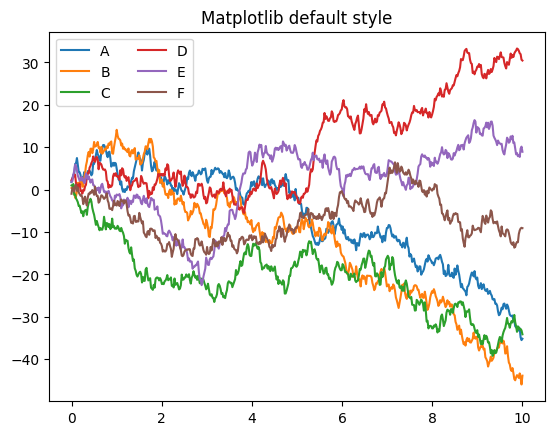

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

plt.figure()
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')
plt.title("Matplotlib default style")
plt.show()

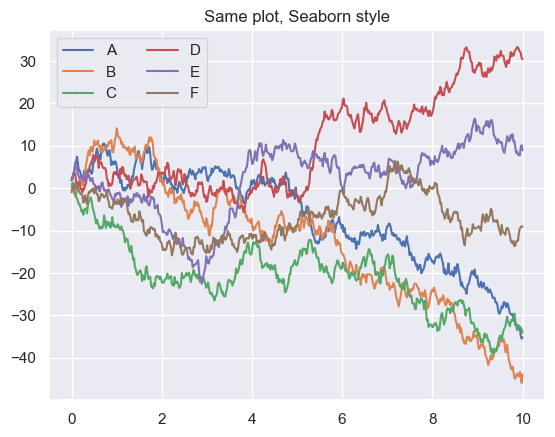

In [3]:
import seaborn as sns
sns.set()  # apply Seaborn styling

plt.figure()
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')
plt.title("Same plot, Seaborn style")
plt.show()

## Part 2 — My own data: MEP & ELV subcontractor tracking
I built a small dataset the way it would look in a weekly progress report: one row per trade package, with planned vs actual progress, open snags, and a delivery-status KPI.

In [4]:
data = pd.DataFrame({
    "Trade":   ["HVAC","Electrical","Plumbing","Fire Fighting","ELV","BMS"],
    "Planned_%": [80, 75, 85, 60, 70, 55],
    "Actual_%":  [72, 78, 80, 45, 66, 40],
    "Open_Snags":[18, 9, 6, 24, 12, 15],
    "Status":   ["At Risk","On Track","On Track","Delayed","On Track","Delayed"],
})
data["Variance_%"] = data["Actual_%"] - data["Planned_%"]
data

,Trade,Planned_%,Actual_%,Open_Snags,Status,Variance_%
0,HVAC,80,72,18,At Risk,-8
1,Electrical,75,78,9,On Track,3
2,Plumbing,85,80,6,On Track,-5
3,Fire Fighting,60,45,24,Delayed,-15
4,ELV,70,66,12,On Track,-4
5,BMS,55,40,15,Delayed,-15


### Matplotlib — Planned vs Actual progress by trade
A grouped bar chart, the kind I'd drop straight into a steering-committee slide.

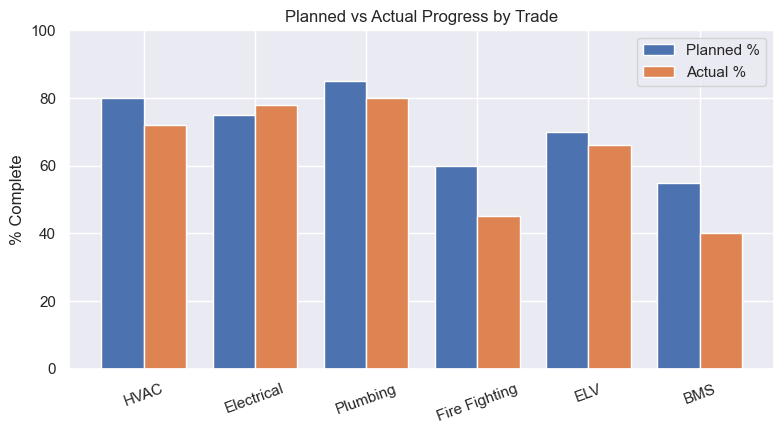

In [5]:
fig, ax = plt.subplots(figsize=(8,4.5))
idx = np.arange(len(data))
w = 0.38
ax.bar(idx - w/2, data["Planned_%"], w, label="Planned %")
ax.bar(idx + w/2, data["Actual_%"], w, label="Actual %")
ax.set_xticks(idx); ax.set_xticklabels(data["Trade"], rotation=20)
ax.set_ylabel("% Complete"); ax.set_ylim(0,100)
ax.set_title("Planned vs Actual Progress by Trade")
ax.legend()
plt.tight_layout(); plt.show()

### Seaborn — schedule variance by trade
Negative bars are trades running behind the baseline. Fire Fighting and BMS are the ones to chase.

C:\Users\Owner\AppData\Local\Temp\ipykernel_25652\612453492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Trade", y="Variance_%", data=data, palette=colors)


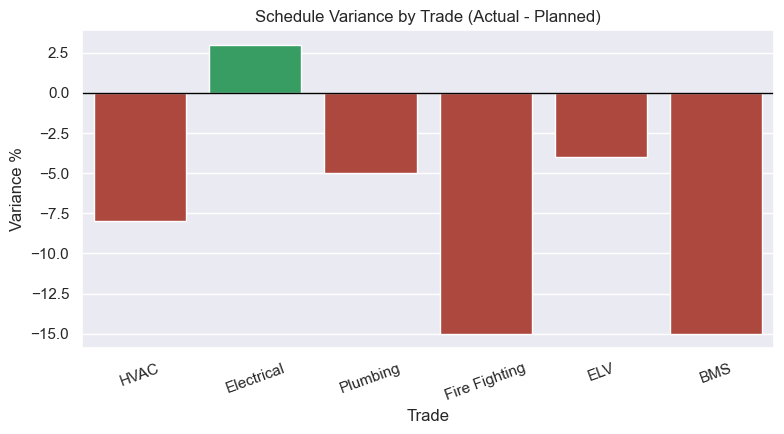

In [6]:
plt.figure(figsize=(8,4.5))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in data["Variance_%"]]
sns.barplot(x="Trade", y="Variance_%", data=data, palette=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Schedule Variance by Trade (Actual - Planned)")
plt.ylabel("Variance %"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

### Seaborn — open snags vs progress
Quick check on whether trades that are further behind also carry more open snags.

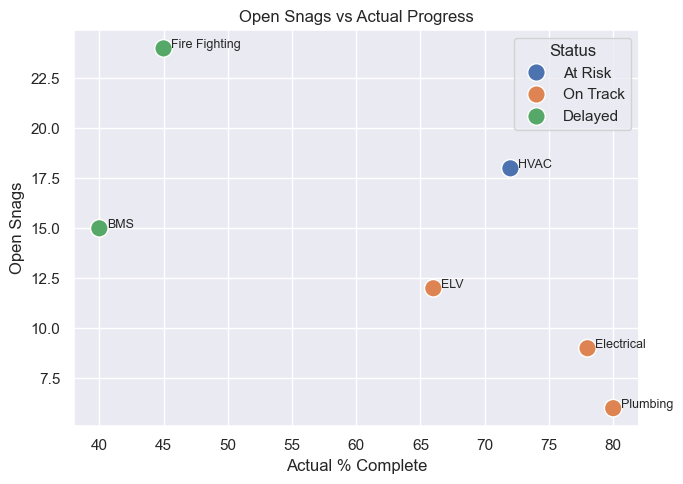

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Actual_%", y="Open_Snags", hue="Status", s=160, data=data)
for _, r in data.iterrows():
    plt.text(r["Actual_%"]+0.6, r["Open_Snags"], r["Trade"], fontsize=9)
plt.title("Open Snags vs Actual Progress")
plt.xlabel("Actual % Complete"); plt.ylabel("Open Snags")
plt.tight_layout(); plt.show()

### Seaborn — weekly S-curve (cumulative progress)
A planned vs actual S-curve over the last weeks, the headline chart in any progress report.

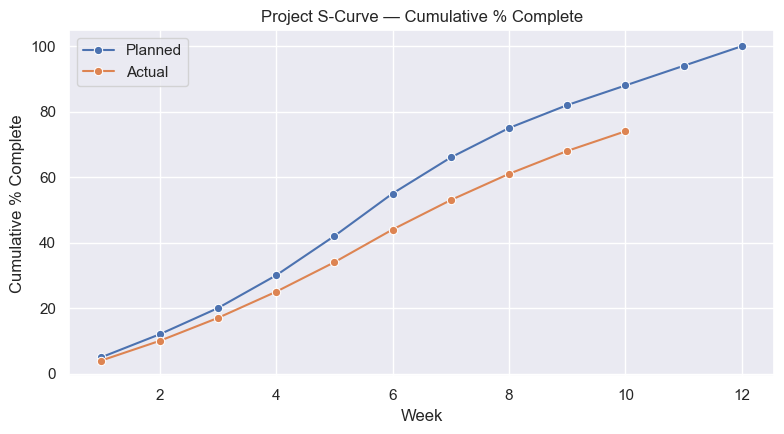

In [8]:
weeks = np.arange(1, 13)
planned_cum = np.array([5,12,20,30,42,55,66,75,82,88,94,100])
actual_cum  = np.array([4,10,17,25,34,44,53,61,68,74,np.nan,np.nan])  # last weeks not yet reported
sc = pd.DataFrame({"Week":weeks, "Planned":planned_cum, "Actual":actual_cum})

plt.figure(figsize=(8,4.5))
sns.lineplot(x="Week", y="Planned", data=sc, marker="o", label="Planned")
sns.lineplot(x="Week", y="Actual",  data=sc, marker="o", label="Actual")
plt.title("Project S-Curve — Cumulative % Complete")
plt.ylabel("Cumulative % Complete"); plt.xlabel("Week")
plt.legend(); plt.tight_layout(); plt.show()

## Part 3 — Folium: project site map
Following the notebook's Folium section, I mapped a few project locations with markers colour-coded by delivery status. Each map is also saved as an HTML file so it can be opened in a browser.

In [11]:
import folium

# Centre roughly on the region; replace coords with real project sites
m = folium.Map(location=[33.8735578, 35.863749], zoom_start=8, tiles="cartodb positron")

sites = [
    ("Data Centre - Phase 1", 33.8938, 35.5018, "On Track", "green"),
    ("Data Centre - Phase 2", 34.4367, 35.8497, "Delayed",  "red"),
    ("MEP Plant Room",        33.5571, 35.3729, "At Risk",  "orange"),
]
for name, lat, lon, status, color in sites:
    folium.Marker(
        location=[lat, lon],
        tooltip=name,
        popup=f"{name} — {status}",
        icon=folium.Icon(color=color, icon="info-sign"),
    ).add_to(m)

m.save("site_map.html")
m